# 03 · Train the shared base model

**Phase 3 goal:** train the shared `GazeNet` on *seen* subjects, then record its honest **before-calibration** gaze error on *never-seen* subjects. That error is the baseline Phase 4's per-user calibration must beat.

- Model: `model/network.py` (1D-CNN → BiLSTM → drift adapter → gaze + blink heads).
- Split: **by subject** — train subjects vs held-out "new user" subjects (report §2.3).
- Normalisation: drift-preserving input normaliser fit on train; gaze targets standardised (so gaze-MSE and blink-BCE are balanced) and inverted back to degrees for reporting.

**Runs on Colab or locally.** Set `SANITY = True` for a quick CPU pipeline check; set `SANITY = False` (ideally on Colab's GPU) for the real training run.

In [ ]:
import sys, time
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
%matplotlib inline

# --- config ---------------------------------------------------------------
SANITY = True                      # True: quick CPU check; False: full run (use Colab GPU)
TRAIN_SUBJECTS   = ['S1', 'S2', 'S3', 'S4']
HELDOUT_SUBJECTS = ['S5', 'S6']    # never-seen 'new users'
BATCH = 64
LR = 1e-3
EPOCHS = 2 if SANITY else 80
SEED = 0

torch.manual_seed(SEED); np.random.seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# locate the project. On Colab: mount Drive and point at the uploaded folder.
try:
    import google.colab  # noqa: F401
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/content/drive/MyDrive/DriftLess_colab')  # <-- change if your Drive folder is named differently
except ImportError:
    ROOT = next((p for p in [Path.cwd(), Path.cwd().parent] if (p / 'model' / 'network.py').exists()), None)
assert ROOT is not None and (ROOT / 'model' / 'network.py').exists(), f'project not found at ROOT={ROOT}'
sys.path.insert(0, str(ROOT))
from model.network import GazeNet, gaze_blink_loss, count_parameters
from model.windowing import load_subject_windows, fit_normaliser, apply_normaliser

PROC = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'; MODELS.mkdir(exist_ok=True)
print(f'device={device}  SANITY={SANITY}  epochs={EPOCHS}')
print(f'train={TRAIN_SUBJECTS}  heldout(new users)={HELDOUT_SUBJECTS}')

## 1 · Assemble the subject-split datasets

Fit both normalisers on the **train** subjects only (no leakage), then apply to everyone.

In [2]:
def stack(subjects):
    Xs, gs, bs = [], [], []
    for s in subjects:
        sw = load_subject_windows(PROC / f'{s}_windows.npz')
        Xs.append(sw.X); gs.append(sw.y_gaze); bs.append(sw.y_blink)
    return np.concatenate(Xs), np.concatenate(gs), np.concatenate(bs)

Xtr, gtr, btr = stack(TRAIN_SUBJECTS)
Xho, gho, bho = stack(HELDOUT_SUBJECTS)

# input normaliser: drift-preserving, fit on train
in_mean, in_std = fit_normaliser(Xtr)
# gaze target scaler: mean/std over TRAIN saccade windows (ignore NaN blink rows)
sacc_tr = btr == 0
g_mean = gtr[sacc_tr].mean(axis=0); g_std = gtr[sacc_tr].std(axis=0)

def make_ds(X, g, b):
    Xn = apply_normaliser(X, in_mean, in_std).astype(np.float32)
    gz = ((g - g_mean) / g_std).astype(np.float32)   # NaN stays NaN on blink rows (masked in loss)
    return TensorDataset(torch.tensor(Xn), torch.tensor(gz), torch.tensor(b))

train_ds, heldout_ds = make_ds(Xtr, gtr, btr), make_ds(Xho, gho, bho)
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
print(f'train windows={len(train_ds)}  heldout windows={len(heldout_ds)}')
print(f'gaze target mean={g_mean.round(2)} std={g_std.round(2)} (degrees)')

train windows=3600  heldout windows=1800
gaze target mean=[0. 0.] std=[13.6   7.68] (degrees)


## 2 · Train

In [3]:
model = GazeNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
print(f'GazeNet: {count_parameters(model):,} params')

hist = []
for epoch in range(EPOCHS):
    model.train(); t0 = time.time(); running = 0.0
    for X, g, b in train_dl:
        X, g, b = X.to(device), g.to(device), b.to(device)
        opt.zero_grad()
        total, gl, bl = gaze_blink_loss(*model(X), g, b)
        total.backward(); opt.step()
        running += total.item() * len(X)
    hist.append(running / len(train_ds))
    print(f'epoch {epoch+1:2d}/{EPOCHS}  train_loss={hist[-1]:.4f}  ({time.time()-t0:.1f}s)')

GazeNet: 144,003 params


epoch  1/2  train_loss=1.4458  (5.0s)


epoch  2/2  train_loss=1.2373  (4.2s)


## 3 · The honest before-calibration baseline (never-seen subjects)

Gaze error is reported as mean Euclidean error in **degrees** (inverting the target scaling); blink as accuracy.

In [4]:
@torch.no_grad()
def evaluate(ds, subjects_label):
    model.eval()
    dl = DataLoader(ds, batch_size=256)
    gp, gt, bp, bt = [], [], [], []
    for X, g, b in dl:
        gaze, blink = model(X.to(device))
        gp.append(gaze.cpu().numpy()); gt.append(g.numpy())
        bp.append((torch.sigmoid(blink).cpu().numpy() > 0.5).astype(int).ravel()); bt.append(b.numpy())
    gp, gt = np.concatenate(gp), np.concatenate(gt)
    bp, bt = np.concatenate(bp), np.concatenate(bt)
    sacc = ~np.isnan(gt).any(axis=1)
    # invert target scaling -> degrees
    gp_deg = gp * g_std + g_mean
    gt_deg = gt * g_std + g_mean
    err = np.linalg.norm((gp_deg - gt_deg)[sacc], axis=1)
    print(f'[{subjects_label}]  gaze mean error = {err.mean():.2f} deg  (median {np.median(err):.2f})'
          f'   blink acc = {(bp==bt).mean()*100:.1f}%')
    return err.mean()

baseline_deg = evaluate(heldout_ds, ' + '.join(HELDOUT_SUBJECTS) + ' (never-seen)')
_ = evaluate(train_ds, 'train (reference)')

[S5 + S6 (never-seen)]  gaze mean error = 10.84 deg  (median 10.47)   blink acc = 66.7%


[train (reference)]  gaze mean error = 8.56 deg  (median 8.52)   blink acc = 66.7%


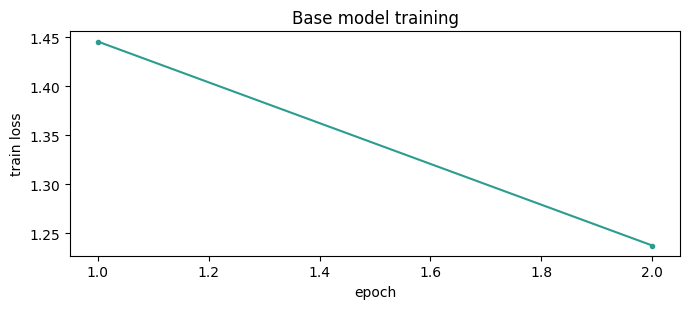

In [5]:
# training curve
plt.figure(figsize=(7, 3.2))
plt.plot(range(1, len(hist)+1), hist, marker='o', ms=3, color='#2a9d8f')
plt.xlabel('epoch'); plt.ylabel('train loss'); plt.title('Base model training')
plt.tight_layout(); plt.show()

## 4 · Save the base model + normalisers (the local model registry)

Saved to `models/` (gitignored — binaries belong in the registry, not git). Phase 4 loads these to calibrate per-user adapters.

In [6]:
torch.save(model.state_dict(), MODELS / 'base_model.pt')
np.savez(MODELS / 'base_norm.npz', in_mean=in_mean, in_std=in_std, g_mean=g_mean, g_std=g_std,
         train_subjects=TRAIN_SUBJECTS, heldout_subjects=HELDOUT_SUBJECTS, sanity=SANITY)
print('saved:', (MODELS / 'base_model.pt').relative_to(ROOT), 'and', (MODELS / 'base_norm.npz').relative_to(ROOT))
if SANITY:
    print('\nNOTE: SANITY run - numbers are NOT meaningful. Set SANITY=False and run on Colab GPU for the real baseline.')

saved: models\base_model.pt and models\base_norm.npz

NOTE: SANITY run - numbers are NOT meaningful. Set SANITY=False and run on Colab GPU for the real baseline.


## Conclusions

- The training pipeline runs end to end: subject-split data → `GazeNet` → balanced gaze+blink loss → before-calibration metric in degrees.
- **Record the held-out `gaze mean error (deg)` from the full (non-sanity) run — that is the "before" number.**

**Next → `04_calibrate.ipynb` (Phase 4):** for each never-seen subject, freeze the backbone and few-shot fine-tune only the drift adapter on ~10 of their trials, then show the gaze error drops vs this baseline — the project's core result.